In [1]:
import torch
import torch.nn as nn

from torch.optim import Adam
from torch.distributions.uniform import Uniform
from torch.utils.data import TensorDataset, DataLoader

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
inputs = torch.eye(4, dtype=torch.float32)
labels = torch.tensor([[0., 1., 0., 0.],
                       [0., 0., 1., 0.],
                       [0., 0., 0., 1.],
                       [0., 1., 0., 0.]])
dataset = TensorDataset(inputs, labels)
dataloader = DataLoader(dataset, batch_size=2, shuffle=True)

In [13]:
inputs[0]

tensor([1., 0., 0., 0.])

In [22]:

    
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        min_val, max_val = -0.5, 0.5
        self.W1 = nn.Parameter(Uniform(min_val, max_val).sample((4, 2)))
        self.W2 = nn.Parameter(Uniform(min_val, max_val).sample((2, 4)))
        self.loss = nn.CrossEntropyLoss()

    def forward(self, X):
        X = X @ self.W1
        X = X @ self.W2
        return X
    
    def configure_optimizers(self):
        return Adam(self.parameters(), lr=0.1)
    
    def training_step(self, batch):
        inputs, labels = batch
        outputs = self(inputs)
        loss = self.loss(outputs, labels.argmax(dim=1))
        return loss

In [23]:
net = Net()
for name, param in net.named_parameters():
    print(name, param)

data = {
    'W1': net.W1[:, 0].detach().cpu().tolist(),
    'W2': net.W1[:, 1].detach().cpu().tolist(),
    'word': ['Troll 2', 'is', 'great', 'Gymkata'],
    'input': ['input1', 'input2', 'input3', 'input4']
}
df = pd.DataFrame(data)
df

W1 Parameter containing:
tensor([[-0.4103, -0.2116],
        [ 0.4674,  0.2149],
        [-0.2786,  0.2623],
        [-0.2201, -0.4358]], requires_grad=True)
W2 Parameter containing:
tensor([[ 0.3765, -0.1872,  0.4345,  0.1712],
        [ 0.0712, -0.0599, -0.0740, -0.0832]], requires_grad=True)


,W1,W2,word,input
0,-0.410307,-0.211584,Troll 2,input1
1,0.467406,0.214900,is,input2
2,-0.278618,0.262260,great,input3
3,-0.220075,-0.435837,Gymkata,input4


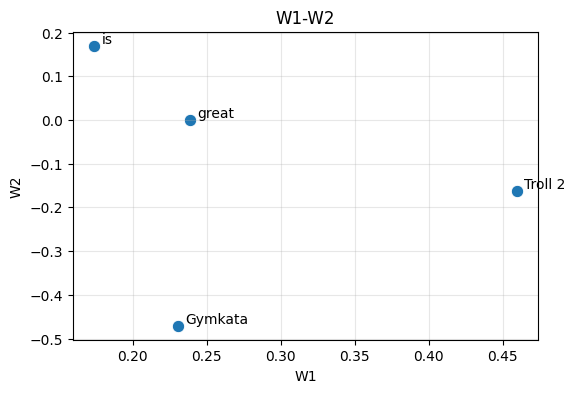

In [21]:
def plot_w1_w2(dataframe, x_col='W1', y_col='W2', text_col='word', offset=0.005, figsize=(6, 4), size=80):
    fig, ax = plt.subplots(figsize=figsize)
    sns.scatterplot(data=dataframe, x=x_col, y=y_col, s=size, ax=ax)

    for _, r in dataframe.iterrows():
        ax.text(r[x_col] + offset, r[y_col] + offset, r[text_col], fontsize=10)

    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_title(f'{x_col}-{y_col}')
    ax.grid(alpha=0.3)
    plt.show()

plot_w1_w2(df)

In [25]:
epochs = 1000
for epoch in range(epochs):
    for batch in dataloader:
        loss = net.training_step(batch)
        loss.backward()
        net.configure_optimizers().step()
        net.configure_optimizers().zero_grad()

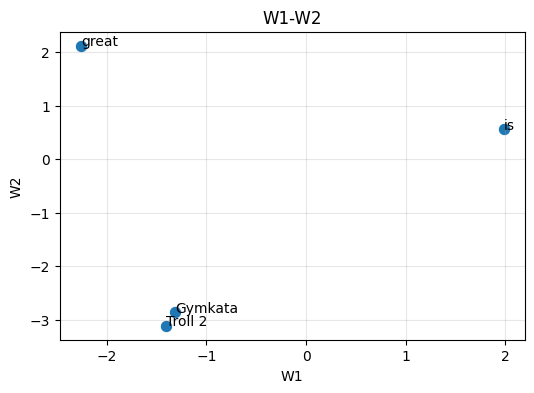

In [26]:
data = {
    'W1': net.W1[:, 0].detach().cpu().tolist(),
    'W2': net.W1[:, 1].detach().cpu().tolist(),
    'word': ['Troll 2', 'is', 'great', 'Gymkata'],
    'input': ['input1', 'input2', 'input3', 'input4']
}
df = pd.DataFrame(data)
plot_w1_w2(df)

In [29]:
test_X = torch.tensor([[1., 0., 0., 0.]])
test_output = net(test_X)
print(test_output.argmax(dim=1).item())

1
